IJCRS graph

In [1]:
%load_ext autoreload
%autoreload 2

In [73]:
from hhelper.tester import calculate_score, count_all_rules, count_all_attributes
from pathlib import Path
from hhelper.scoring import balanced_accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')


In [74]:
def plot_performance(data:pd.DataFrame, hyperparam_col="Ratio", metric_col="Balanced accuracy"):
    """
    Plots the performance of a model against a hyperparameter.

    Parameters:
        df (pd.DataFrame): DataFrame containing the hyperparameter values and performance metric.
        hyperparam_col (str): Column name for the hyperparameter.
        metric_col (str): Column name for the performance metric.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(data[hyperparam_col], data[metric_col], marker='o', linestyle='-', color='b', label=metric_col)

    plt.xlabel(hyperparam_col)
    plt.ylabel(metric_col)
    plt.title(f'{metric_col} vs {hyperparam_col}')
    plt.xticks(data[hyperparam_col])  # Ensure x-ticks match hyperparameter values
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

In [75]:
data_sets = [  # actual set for QR
    'australian',
     'bands',
     'bupa',
     'cleveland',
     'dermatology',
     'ecoli',
     'glass',
     'heart',
     'ionosphere',
     'pima',
     'sonar',
     'spectfheart',
     'vehicle',
     'vowel',
     'wine',
     'winequality-red',
     'wisconsin',
     'yeast'
]

In [76]:
data_base = Path.cwd() / 'keel-data'
metric = balanced_accuracy_score
scores = {}
rules = {}
attributes = {}
results_base = Path.cwd() / 'results'

In [77]:
frri_models = {
    'control': Path.cwd() / 'results' / 'multiclassMSECVXgran' / 'control-does-the-old-work',
    'ofrfs-1' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs',
    'ofrfs-0.9': Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.9',
    'ofrfs-0.8': Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.8',
    'ofrfs-0.7' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.7',
    'ofrfs-0.6' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.6',
    'ofrfs-0.5': Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.5',
    'ofrfs-0.4': Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.4',
    'ofrfs-0.3' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.3',
    'ofrfs-0.2' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.2',
    'ofrfs-0.1' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0.1',
    'ofrfs-0' : Path.cwd() / 'results' / 'ijcrs-retest' / 'ofrfs-0',
}

In [78]:
for model, path in frri_models.items():
    print(model)
    scores[model] = calculate_score(
        data_folder=Path.cwd() / 'keel-data',
        results_folder=path,
        metric=metric,
        include=data_sets,
        label_encoding=True
    )
    # rules[model] = count_all_rules(
    #     path,
    #     include=data_sets
    # )
    # attributes[model] = count_all_attributes(
    #     path,
    #     include=data_sets,
    #     counter='attribute'
    # )

control
ofrfs-1
ofrfs-0.9
ofrfs-0.8
ofrfs-0.7
ofrfs-0.6
ofrfs-0.5
ofrfs-0.4
ofrfs-0.3
ofrfs-0.2
ofrfs-0.1
ofrfs-0


In [79]:
ijcrs =  [
    # 'control',
    'ofrfs-1',
    'ofrfs-0.9',
    'ofrfs-0.8',
    'ofrfs-0.7',
    'ofrfs-0.6',
    'ofrfs-0.5',
    'ofrfs-0.4',
    'ofrfs-0.3',
    'ofrfs-0.2',
    'ofrfs-0.1',
    'ofrfs-0',
]
ijcrs.reverse()

In [80]:
table_acc = pd.DataFrame(index=data_sets, columns=ijcrs)
for model in ijcrs:
    for data_set in data_sets:
        table_acc.loc[data_set, model] = scores[model][data_set]
table_acc.loc['mean'] = table_acc.mean(axis='rows', skipna=True)

# table_rule = pd.DataFrame(index=data_sets, columns=ijcrs)
# for model in ijcrs:
#     for data_set in data_sets:
#         table_rule.loc[data_set, model] = rules[model][data_set]  #  rule_count
# table_rule.loc['mean'] = table_rule.mean(axis='rows', skipna=True)
#
# table_attribute = pd.DataFrame(index=data_sets, columns=names[nr])
# for model in names[nr]:
#     for data_set in data_sets:
#         table_attribute.loc[data_set, model] = attributes[model][data_set]
# table_attribute.loc['mean'] = table_attribute.mean(axis='rows', skipna=True)

In [81]:
table_acc.loc['mean'].values

array([0.5249590753192863, 0.5043883701229189, 0.41480800532781065,
       0.5798446471205274, 0.6361385162631003, 0.6517439486876628,
       0.672941866535641, 0.6809312586997177, 0.6927722170572547,
       0.71255225176172, 0.6986416985476812], dtype=object)

In [89]:
def plot_performance(df, hyperparam_col="Ratio", metric_col="Balanced accuracy", save_path=None):
    """
    Plots the performance of a model against a hyperparameter.

    Parameters:
        df (pd.DataFrame): DataFrame containing the hyperparameter values and performance metric.
        hyperparam_col (str): Column name for the hyperparameter.
        metric_col (str): Column name for the performance metric.
        save_path (str, optional): File path to save the figure (e.g., 'figure.pdf').
    """
    plt.figure(figsize=(8, 5))
    plt.plot(df[hyperparam_col], df[metric_col], marker='o', linestyle='-', color='b', label=metric_col)

    plt.xlabel(hyperparam_col, labelpad=20)
    plt.ylabel(metric_col, labelpad=20)
    # plt.title(f'{metric_col} vs {hyperparam_col}')
    plt.xticks(df[hyperparam_col])  # Ensure x-ticks match hyperparameter values
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.legend()
    if save_path:
        plt.savefig(save_path, format=str(save_path).split('.')[-1], bbox_inches='tight', transparent=True)  # Save in the specified format

    plt.show()

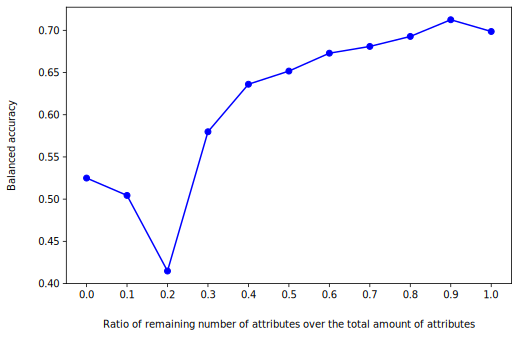

In [92]:
data = {
    "Ratio of remaining number of attributes over the total amount of attributes": [0] + [i / 10 for i in range(1,11)],  # 0.0 to 1.0 in steps of 0.1
    "Balanced accuracy": table_acc.loc['mean'].values
}
df = pd.DataFrame(data)

plot_performance(df, hyperparam_col="Ratio of remaining number of attributes over the total amount of attributes", save_path=Path.cwd() / 'figures' / 'ba-plot.svg')
